Task 2.5 - Data Cleaning and Visualization Using (R) - 03-15-2026 - urzraz2644

In [1]:
library(readxl)
airbnb <- read_excel("AirBnB_Cleaned.xlsx")
head(airbnb)


id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,<StudentID>
<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
7909479,41706311,David,Downtown,Entire home/apt,107,30,27,365,urzraz2644
15966488,103700433,Erin,Downtown,Entire home/apt,100,1,250,74,urzraz2644
19859814,103700433,Erin,Downtown,Entire home/apt,100,1,309,79,urzraz2644
21071138,22992627,Joseph,Downtown,Entire home/apt,100,2,144,338,urzraz2644
21712505,103700433,Erin,Downtown,Entire home/apt,100,1,178,68,urzraz2644
25771375,140728885,Rick,Downtown,Entire home/apt,95,2,216,246,urzraz2644


In [2]:
airbnb <- unique(airbnb)
head(airbnb)

id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,<StudentID>
<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
7909479,41706311,David,Downtown,Entire home/apt,107,30,27,365,urzraz2644
15966488,103700433,Erin,Downtown,Entire home/apt,100,1,250,74,urzraz2644
19859814,103700433,Erin,Downtown,Entire home/apt,100,1,309,79,urzraz2644
21071138,22992627,Joseph,Downtown,Entire home/apt,100,2,144,338,urzraz2644
21712505,103700433,Erin,Downtown,Entire home/apt,100,1,178,68,urzraz2644
25771375,140728885,Rick,Downtown,Entire home/apt,95,2,216,246,urzraz2644


In [3]:
airbnb$price[is.na(airbnb$price)] <- median(airbnb$price, na.rm = TRUE)
airbnb$number_of_reviews[is.na(airbnb$number_of_reviews)] <- median(airbnb$number_of_reviews, na.rm = TRUE)
airbnb$minimum_nights[is.na(airbnb$minimum_nights)] <- median(airbnb$minimum_nights, na.rm = TRUE)

summary(airbnb)

       id               host_id           host_name         neighbourhood     
 Min.   :9.068e+04   Min.   :    78761   Length:1657        Length:1657       
 1st Qu.:4.720e+07   1st Qu.: 63469270   Class :character   Class :character  
 Median :6.180e+17   Median :188927124   Mode  :character   Mode  :character  
 Mean   :4.343e+17   Mean   :219320679                                        
 3rd Qu.:7.818e+17   3rd Qu.:381761502                                        
 Max.   :9.212e+17   Max.   :519861666                                        
  room_type             price       minimum_nights    number_of_reviews
 Length:1657        Min.   : 20.0   Min.   :  1.000   Min.   :  0.00   
 Class :character   1st Qu.: 82.0   1st Qu.:  1.000   1st Qu.:  5.00   
 Mode  :character   Median :110.0   Median :  2.000   Median : 20.00   
                    Mean   :124.1   Mean   :  5.926   Mean   : 55.89   
                    3rd Qu.:159.0   3rd Qu.:  2.000   3rd Qu.: 67.00   
               

In [4]:
airbnb$host_name <- tools::toTitleCase(tolower(airbnb$host_name))
airbnb$neighbourhood <- tools::toTitleCase(tolower(airbnb$neighbourhood))
airbnb$room_type <- tools::toTitleCase(tolower(airbnb$room_type))

head(airbnb)

id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,<StudentID>
<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
7909479,41706311,David,Downtown,Entire Home/Apt,107,30,27,365,urzraz2644
15966488,103700433,Erin,Downtown,Entire Home/Apt,100,1,250,74,urzraz2644
19859814,103700433,Erin,Downtown,Entire Home/Apt,100,1,309,79,urzraz2644
21071138,22992627,Joseph,Downtown,Entire Home/Apt,100,2,144,338,urzraz2644
21712505,103700433,Erin,Downtown,Entire Home/Apt,100,1,178,68,urzraz2644
25771375,140728885,Rick,Downtown,Entire Home/Apt,95,2,216,246,urzraz2644


In [8]:
library(writexl)
        
airbnb <- airbnb[airbnb$price < 500, ]

write_xlsx(airbnb, "Airbnb_Cleaned_Final.xlsx")

head(airbnb)

id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,<StudentID>
<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
7909479,41706311,David,Downtown,Entire Home/Apt,107,30,27,365,urzraz2644
15966488,103700433,Erin,Downtown,Entire Home/Apt,100,1,250,74,urzraz2644
19859814,103700433,Erin,Downtown,Entire Home/Apt,100,1,309,79,urzraz2644
21071138,22992627,Joseph,Downtown,Entire Home/Apt,100,2,144,338,urzraz2644
21712505,103700433,Erin,Downtown,Entire Home/Apt,100,1,178,68,urzraz2644
25771375,140728885,Rick,Downtown,Entire Home/Apt,95,2,216,246,urzraz2644


In [9]:
cat("Total Listings:", nrow(airbnb), "\n")
cat("Minimum Price:", min(airbnb$price), "\n")
cat("Maximum Price:", max(airbnb$price), "\n")
cat("Mean Price:", mean(airbnb$price), "\n")
cat("Median Reviews:", median(airbnb$number_of_reviews), "\n")

mode_nights <- names(sort(table(airbnb$minimum_nights), decreasing = TRUE))[1]
cat("Mode Minimum Nights:", mode_nights, "\n")

cat("Standard Deviation Price:", sd(airbnb$price), "\n")
cat("Correlation Price vs Availability:", cor(airbnb$price, airbnb$availability_365), "\n")

Total Listings: 1657 
Minimum Price: 20 
Maximum Price: 308 
Mean Price: 124.1328 
Median Reviews: 20 
Mode Minimum Nights: 1 
Standard Deviation Price: 61.49677 
Correlation Price vs Availability: 0.1064181 


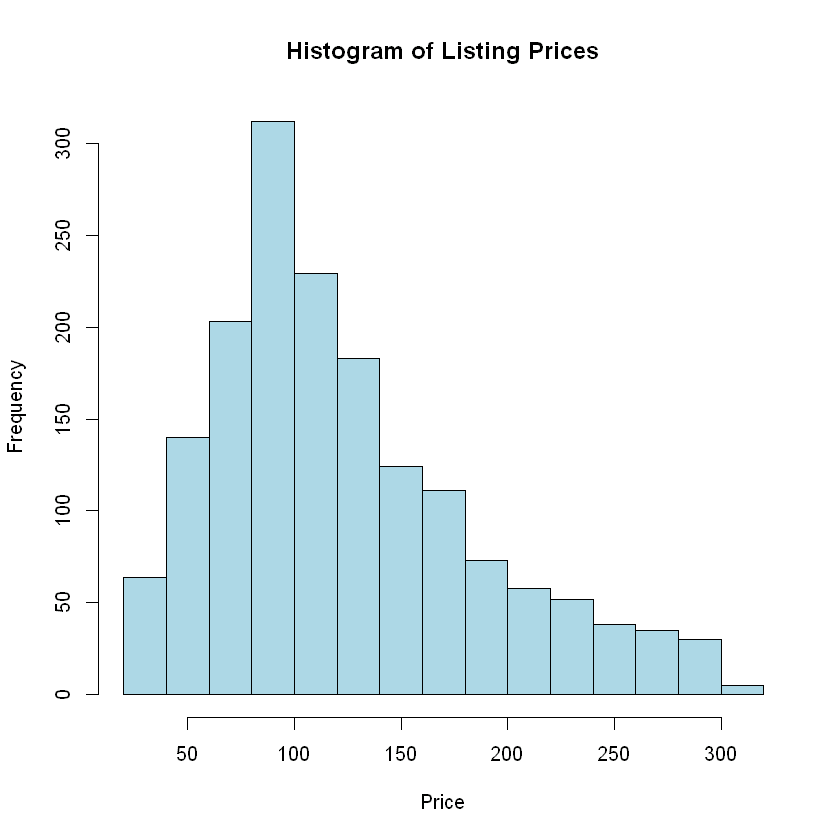

In [11]:
hist(airbnb$price,
     main = "Histogram of Listing Prices",
     xlab = "Price",
     col = "lightblue",
     border = "black")

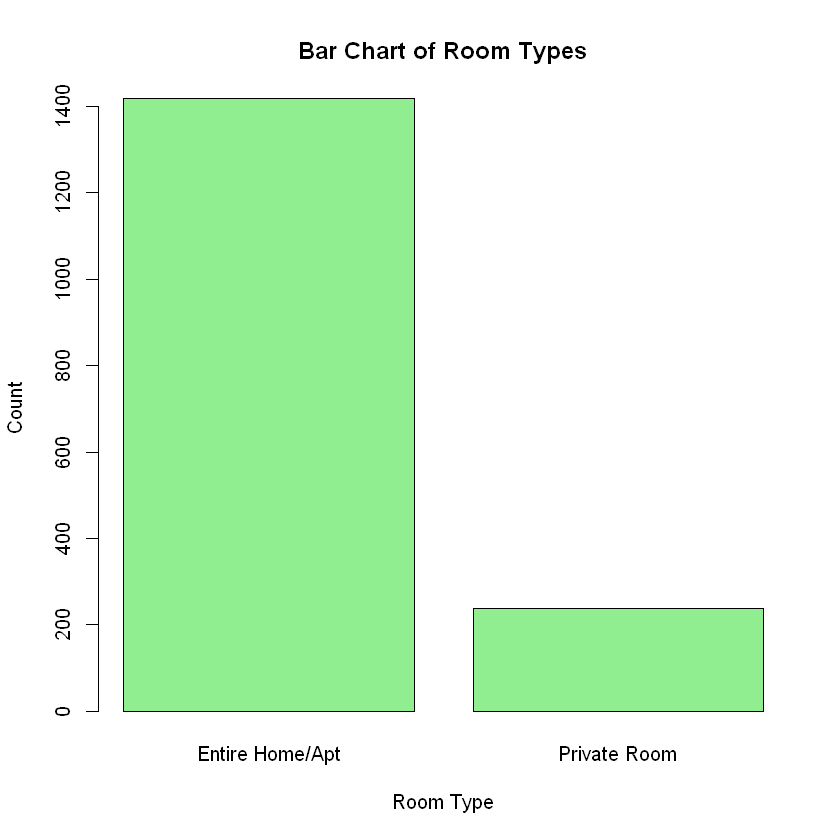

In [12]:
barplot(table(airbnb$room_type),
        main = "Bar Chart of Room Types",
        xlab = "Room Type",
        ylab = "Count",
        col = "lightgreen")

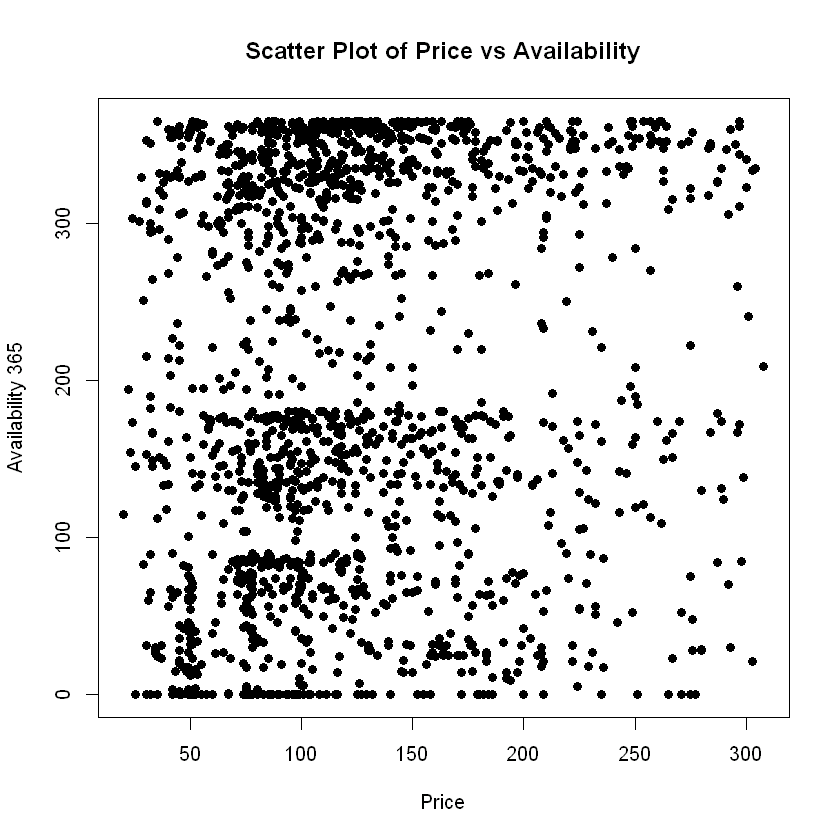

In [13]:
plot(airbnb$price, airbnb$availability_365,
     main = "Scatter Plot of Price vs Availability",
     xlab = "Price",
     ylab = "Availability 365",
     pch = 19)

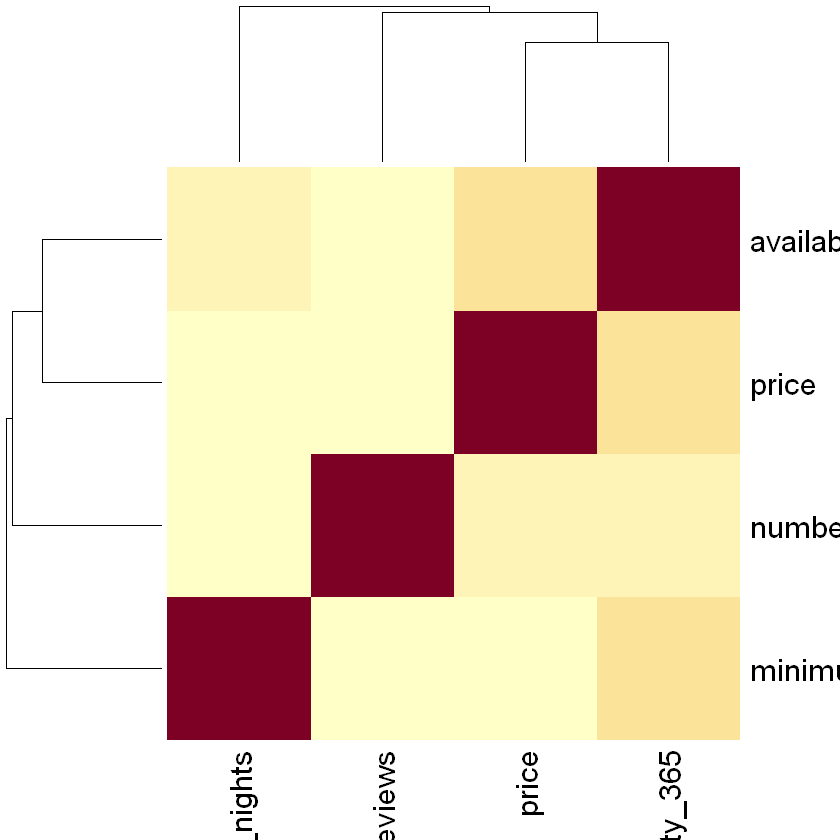

In [14]:
numeric_data <- airbnb[, c("price", "minimum_nights", "number_of_reviews", "availability_365")]

cor_matrix <- cor(numeric_data)

heatmap(cor_matrix)